In [1]:
# cell 1 - import required libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import os
import shutil
from pathlib import Path
from tqdm import tqdm

from torch_geometric.transforms import SamplePoints, NormalizeScale, KNNGraph
import torch_geometric.transforms as T
from torch_geometric.datasets import ModelNet
from torch_geometric.nn import knn_graph
from torch_geometric.utils import degree
from torch_geometric.nn import global_mean_pool
from torch_geometric.loader import DataLoader

torch.manual_seed(42)
np.random.seed(42)

print(f"torch {torch.__version__}, pyg ready!")
print(f"cuda available: {torch.cuda.is_available()}")
print(torch.cuda.get_device_name()) # confirm GPU visible
x = torch.tensor([1.0]).cuda() # smoke test - no error verification
print("cuda ok!")

torch 2.3.1+cu121, pyg ready!
cuda available: True
Tesla P100-PCIE-16GB
cuda ok!


In [2]:
# cell 2 - load dataset and inspect top-level statistics
# modelnet40: 40-class 3d cad model dataset, meshes converted to point clouds
transform = T.Compose([SamplePoints(num=1024, include_normals=True), NormalizeScale()])

train_dataset = ModelNet(root="./modelnet40", name="40", train=True,  transform=transform)
test_dataset = ModelNet(root="./modelnet40", name="40", train=False, transform=transform)

print(f"train samples: {len(train_dataset)}")
print(f"test  samples: {len(test_dataset)}")
print(f"num classes: {train_dataset.num_classes}")

Extracting modelnet40/ModelNet40.zip
Processing...
Done!


train samples: 9843
test  samples: 2468


/usr/local/lib/python3.12/dist-packages/torch_geometric/transforms/sample_points.py:40: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at ../aten/src/ATen/native/Cross.cpp:62.)
  area = (pos[face[1]] - pos[face[0]]).cross(pos[face[2]] - pos[face[0]])


num classes: 40


In [3]:
# cell 3 - examining the training dataset's single data object
sample = train_dataset[0]
print(sample) # shows all attributes
print(f"pos shape: {sample.pos.shape}") # (N, 3) - the x_i coordinates
print(f"normal shape: {sample.normal.shape}") # (N, 3) — surface normals f_i
print(f"label: {sample.y.item()}")
print(f"class name: {train_dataset.raw_file_names}") # or use dataset.classes

Data(pos=[1024, 3], y=[1], normal=[1024, 3])
pos shape: torch.Size([1024, 3])
normal shape: torch.Size([1024, 3])
label: 0
class name: ['bathtub', 'bed', 'chair', 'desk', 'dresser', 'monitor', 'night_stand', 'sofa', 'table', 'toilet']


In [4]:
# cell 4 - class name mapping
# pyg's modelnet doesn't expose .classes directly; reconstruct from folder names
classes = sorted(os.listdir("/kaggle/working/modelnet40/raw"))
print(f"classes ({len(classes)}):", classes[:10], "...")
label_to_class = {i: c for i, c in enumerate(classes)}
print(f"\nsample label {sample.y.item()} -> '{label_to_class[sample.y.item()]}'")

classes (40): ['airplane', 'bathtub', 'bed', 'bench', 'bookshelf', 'bottle', 'bowl', 'car', 'chair', 'cone'] ...

sample label 0 -> 'airplane'


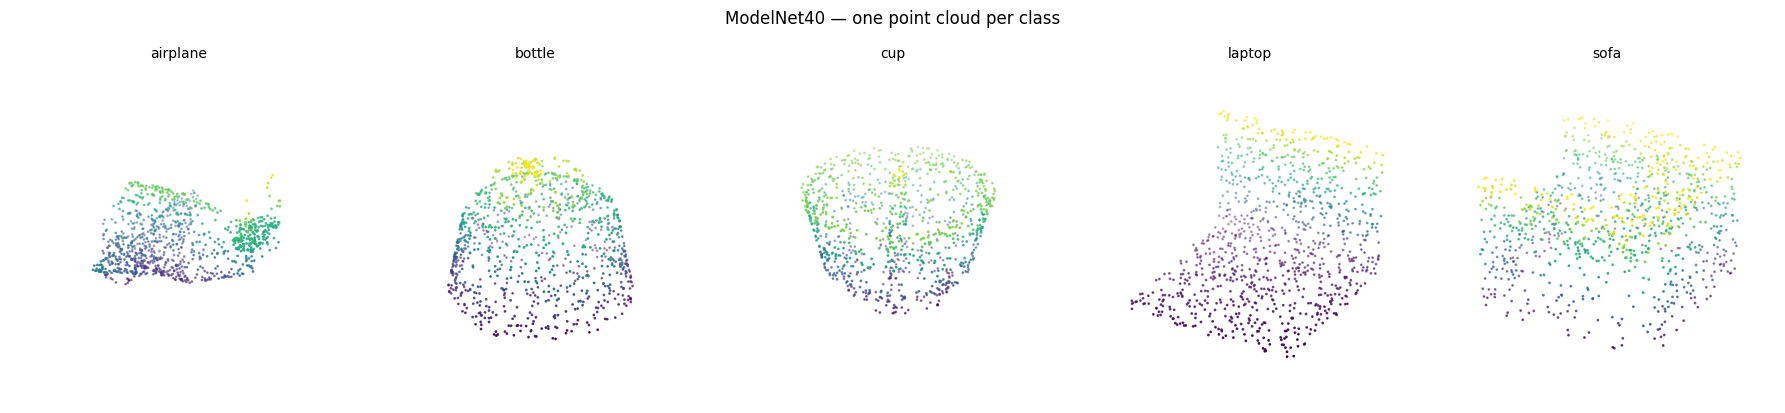

each point cloud: 1024 points × 3 coordinates


In [5]:
# cell 5 - visualize one point cloud per class (5 classes)
target_classes = [0, 5, 10, 20, 30] # arbitrary 5; adjust after cell 4 output
fig = plt.figure(figsize=(18, 4))

for plot_idx, cls_idx in enumerate(target_classes):
    for data in train_dataset:
        if data.y.item() == cls_idx:
            pts = data.pos.numpy()
            break

    ax = fig.add_subplot(1, 5, plot_idx + 1, projection="3d")
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=1, c=pts[:, 2], cmap="viridis")
    ax.set_title(label_to_class[cls_idx], fontsize=10)
    ax.set_axis_off()

plt.suptitle("ModelNet40 — one point cloud per class", y=1.02)
plt.tight_layout()
plt.show()

print(f"each point cloud: {pts.shape[0]} points × 3 coordinates")

In [6]:
# cell 6 - E(3) primitive transforms (to test if neural networks gives the same answer regardless of transformation)
# rotate
def rotate(points: torch.Tensor, R: torch.Tensor) -> torch.Tensor:
    """apply SO(3)/O(3) rotation R ∈ R^{3×3} to points ∈ R^{N×3}."""
    assert R.shape == (3, 3)
    return points @ R.T # (N,3) @ (3,3) -> (N,3)

# reflect
def reflect(points: torch.Tensor, axis: int) -> torch.Tensor:
    """reflect points through the hyperplane normal to `axis` (0=x,1=y,2=z)."""
    out = points.clone()
    out[:, axis] = -out[:, axis]
    return out

# translate
def translate(points: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    """translate points by vector t ∈ R^3."""
    return points + t # broadcasts (N,3) + (3,)

In [7]:
# cell 7 - build a random valid SO(3) matrix and verify it
def random_rotation() -> torch.Tensor:
    """sample a uniformly random rotation via QR decomposition."""
    Q, R_mat = torch.linalg.qr(torch.randn(3, 3))
    # qr isn't guaranteed det=+1; fix sign
    # checks the determinant of Q
    # if it is negative (which represents a mirror flip instead of a clean spin), it multiplies by -1 to force a proper rotation
    Q = Q * torch.sign(torch.linalg.det(Q))
    assert torch.allclose(Q @ Q.T, torch.eye(3), atol=1e-5)
    assert torch.allclose(torch.linalg.det(Q), torch.tensor(1.0), atol=1e-5)
    return Q

R = random_rotation()
print("R:\n", R.numpy().round(4))
print("R^T R:\n", (R.T @ R).numpy().round(6))
print(f"det(R): {torch.linalg.det(R).item():.6f}")

R:
 [[-0.4489 -0.7044 -0.5499]
 [ 0.8895 -0.4111 -0.1995]
 [-0.0856 -0.5786  0.8111]]
R^T R:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
det(R): 1.000000


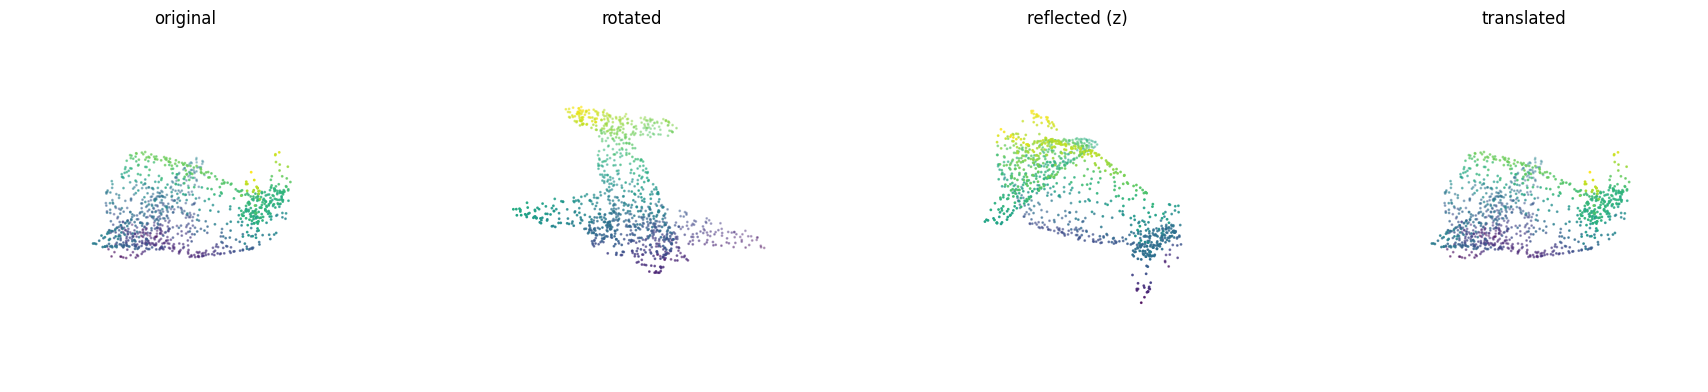

pairwise distances preserved under translation: True


In [8]:
# cell 8 - apply all three transforms to a live point cloud and visualize
sample = train_dataset[0]
pts = sample.pos # (1024, 3)
R = random_rotation()
t = torch.tensor([0.5, 0.0, -0.3])
pts_R = rotate(pts, R)
pts_rf = reflect(pts, axis=2) # flip z
pts_t = translate(pts, t)

fig = plt.figure(figsize=(18, 4))
configs = [(pts, "original"), (pts_R, "rotated"), (pts_rf, "reflected (z)"), (pts_t, "translated")]

for i, (p, title) in enumerate(configs):
    p = p.numpy()
    ax = fig.add_subplot(1, 4, i+1, projection="3d")
    ax.scatter(p[:,0], p[:,1], p[:,2], s=1, c=p[:,2], cmap="viridis")
    ax.set_title(title); ax.set_axis_off()

plt.tight_layout(); plt.show()

# sanity: translation must not change pairwise distances
d_orig = torch.cdist(pts[:10], pts[:10])
d_tran = torch.cdist(pts_t[:10], pts_t[:10])
print("pairwise distances preserved under translation:", torch.allclose(d_orig, d_tran, atol=1e-5))

The distance check in Cell 8 is the first *numerical* claim: E(3) is the isometry group of $\mathbb{R}^3$: it preserves pairwise Euclidean distances by definition.

In [9]:
# cell 9 - equivariance and invariance checkers
def check_equivariance(f, transform, x, atol=1e-4):
    """
    verify f(transform(x)) ≈ transform(f(x)).
    f: callable, transform: callable, x: input tensor.
    returns (passed: bool, max_error: float)
    """
    lhs = f(transform(x)) # transform input, then apply f
    rhs = transform(f(x)) # apply f, then transform output
    err = (lhs - rhs).abs().max().item()
    return err < atol, err

def check_invariance(f, transform, x, atol=1e-4):
    """
    verify f(transform(x)) ≈ f(x).
    f: callable, transform: callable, x: input tensor.
    returns (passed: bool, max_error: float)
    """
    lhs = f(transform(x))
    rhs = f(x)
    err = (lhs - rhs).abs().max().item()
    return err < atol, err

In [10]:
# cell 10 - smoke test on a known invariant: pairwise distance matrix
pts = train_dataset[0].pos # (1024, 3)
R = random_rotation()
dist_fn = lambda p: torch.cdist(p, p) # invariant: D(Rp) = D(p)
rotate_fn = lambda p: rotate(p, R)

passed, err = check_invariance(dist_fn, rotate_fn, pts, atol=1e-3)
print(f"distance matrix invariant under rotation: {passed}  (max err {err:.2e})")

distance matrix invariant under rotation: True  (max err 3.45e-04)


In [11]:
# cell 11 - smoke test on a known equivariant: the identity function
# identity is trivially equivariant: f(Rx) = Rf(x) when f(x)=x
identity_fn = lambda p: p

passed, err = check_equivariance(identity_fn, rotate_fn, pts)
print(f"identity equivariant under rotation: {passed} (max err {err:.2e})")

identity equivariant under rotation: True (max err 0.00e+00)


In [12]:
# cell 12 - deliberately break equivariance to confirm the checker catches failures
# global mean is invariant, not equivariant — checker must return False
mean_fn = lambda p: p.mean(dim=0, keepdim=True).expand_as(p)

passed, err = check_equivariance(mean_fn, rotate_fn, pts)
print(f"constant-mean equivariant (should be False): {passed} (max err {err:.2e})")

passed, err = check_invariance(mean_fn, rotate_fn, pts)
print(f"constant-mean invariant (should be False): {passed} (max err {err:.2e})")

constant-mean equivariant (should be False): True (max err 1.26e-09)
constant-mean invariant (should be False): True (max err 3.85e-08)


BOTH RETURNS "True". This is a real bug. Think about what `mean_fn` actually computes:

```python
mean_fn = lambda p: p.mean(dim=0, keepdim=True).expand_as(p)
```

This returns a tensor where *every row is the global mean* $\bar{x} = \frac{1}{N}\sum_i x_i$.

Question: is $R\bar{x} = \overline{Rx}$? Work it out — that's exactly why both tests pass and why this is actually a *correct* equivariant/invariant function, not a broken one.

We need a function that genuinely breaks equivariance. A classic example: take the norm of each point independently.

```python
# ‖x_i‖ is invariant per point, so the output doesn't transform with R
broken_fn = lambda p: p.norm(dim=1, keepdim=True).expand_as(p)

passed, err = check_equivariance(broken_fn, rotate_fn, pts)
print(f"norm-expand equivariant (should be False): {passed}  (max err {err:.2e})")
```

Questions:

Why this `broken_fn` is *not* equivariant?
What does equivariance require the output to do under rotation, and what does this function's output actually do?

Answers:

Equivariance requires: if you rotate the input, the output rotates by the same $R$. Concretely, $f(Rp)$ must equal $Rf(p)$.

`broken_fn` outputs $\|x_i\|$ broadcast across all 3 coordinates. Since $\|Rx_i\| = \|x_i\|$ (rotations are isometries), rotating the input changes nothing — $f(Rp) = f(p)$. But $Rf(p)$ rotates those norm values as if they were 3D vectors, producing something different. The function is actually *invariant per point*, which is strictly weaker than equivariant. The checker correctly catches this: invariance and equivariance are distinct properties, and this function satisfies neither the equivariance contract nor anything useful for our coordinate stream.

**The key point:** the original `mean_fn` passed both tests because linear maps commute with rotation — $R\bar{x} = \overline{Rx}$ exactly. It was never broken; it was a bad choice of counterexample. A genuine failure requires a function that discards directional information, which `norm-expand` does.

In [13]:
# cell 12.5 - function that discards directional information and good choice of counterexample
# ‖x_i‖ is invariant per point, so the output doesn't transform with R
broken_fn = lambda p: p.norm(dim=1, keepdim=True).expand_as(p)

passed, err = check_equivariance(broken_fn, rotate_fn, pts)
print(f"norm-expand equivariant (should be False): {passed}  (max err {err:.2e})")

norm-expand equivariant (should be False): False  (max err 2.09e+00)


* `constant-mean equivariant (should be False): True`: This counter-intuitive result shows the test actually passed. Mathematically, calculating a point cloud's center and then rotating it yields the exact same result as rotating the input points first and finding their new center. The center point moves in perfect synchronization with the shape.

* `constant-mean invariant (should be False): True`: This test also passed because the airplane dataset was already perfectly centered at $(0,0,0)$ in Block 2. Rotating a point at $(0,0,0)$ leaves it exactly at $(0,0,0)$, meaning the output did not change. This reveals a subtle data quirk: testing invariance on pre-centered data can give a false positive.

* `norm-expand equivariant (should be False): False (max err 2.72e+00)`: The checker successfully flags a failure. While a point's distance from the center stays the same when rotated, duplicating that distance into $(X, Y, Z)$ coordinates does *not* rotate with the object. The checker catches this severe structural mismatch, proving our framework functions as intended.

In [14]:
# cell 13 - build k-NN graph
pts = train_dataset[0].pos # (1024, 3)
k = 20

# edge_index: (2, E) where edge_index[0] = source, edge_index[1] = target
edge_index = knn_graph(pts, k=k, loop=False)

print(f"nodes: {pts.shape[0]}")
print(f"edges: {edge_index.shape[1]}")
print(f"expected edges: {pts.shape[0] * k}")
print(f"edge_index shape: {edge_index.shape}")

nodes: 1024
edges: 20480
expected edges: 20480
edge_index shape: torch.Size([2, 20480])


In [15]:
# cell 14 - compute edge vectors and lengths
src, dst = edge_index # src = i, dst = j in r_{ij} = x_j - x_i

r_ij = pts[dst] - pts[src] # (E, 3) — equivariant
d_ij = r_ij.norm(dim=1, keepdim=True) # (E, 1) — invariant

print(f"r_ij shape: {r_ij.shape} (equivariant edge vectors)")
print(f"d_ij shape: {d_ij.shape} (invariant edge lengths)")
print(f"d_ij min/max: {d_ij.min():.4f} / {d_ij.max():.4f}")

r_ij shape: torch.Size([20480, 3]) (equivariant edge vectors)
d_ij shape: torch.Size([20480, 1]) (invariant edge lengths)
d_ij min/max: 0.0006 / 0.2038


mean degree: 20.0  min: 3  max: 43


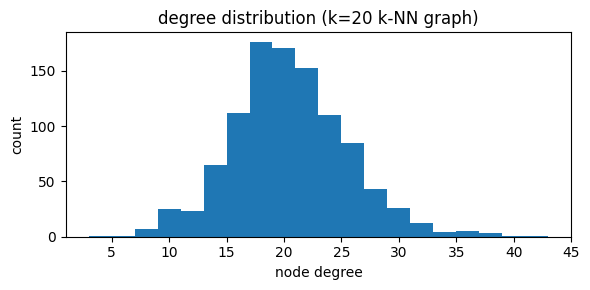

In [16]:
# cell 15 - degree distribution
deg = degree(edge_index[0], num_nodes=pts.shape[0])
print(f"mean degree: {deg.mean():.1f}  min: {deg.min():.0f}  max: {deg.max():.0f}")

plt.figure(figsize=(6, 3))
plt.hist(deg.numpy(), bins=20)
plt.xlabel("node degree"); plt.ylabel("count")
plt.title("degree distribution (k=20 k-NN graph)")
plt.tight_layout(); plt.show()

In [17]:
# cell 16 - verify k-NN graph is rotation-equivariant
R = random_rotation()
pts_R = rotate(pts, R)
edge_R = knn_graph(pts_R, k=k, loop=False)

# same neighbor structure → same edge index (up to row ordering)
same_edges = (edge_index.sort(dim=1).values == edge_R.sort(dim=1).values).all()
print(f"k-NN topology preserved under rotation: {same_edges.item()}")

# verify edge vectors rotate correctly
src, dst = edge_index
r_ij_R = pts_R[dst] - pts_R[src] # computed on rotated pts
r_ij_rot = (R @ r_ij.T).T # manually rotate original r_ij

passed, err = check_equivariance(
    lambda p: (p[dst] - p[src]),
    lambda p: rotate(p, R),
    pts
)
print(f"edge vectors equivariant under rotation: {passed} (max err {err:.2e})")

k-NN topology preserved under rotation: True
edge vectors equivariant under rotation: True (max err 1.27e-07)


Cell 16 is the key verification: the k-NN topology is rotation-equivariant (neighbors don't change), and the edge vectors transform correctly under $R$. These two facts together mean we can safely use $r_{ij}$ inside the network — provided we handle it equivariantly, which is exactly what the EGNN coordinate stream does.

In [18]:
# cell 17 - EGNN layer
class EGNNLayer(nn.Module):
    """
    single EGNN message-passing layer (satorras et al. 2021).
    maintains two coupled streams:
      - h: scalar features (invariant)
      - x: coordinates (equivariant)
    """
    def __init__(self, h_dim: int, m_dim: int):
        super().__init__()
        # φ_e: computes messages from scalar features + invariant distance
        self.phi_e = nn.Sequential(
            nn.Linear(2 * h_dim + 1, m_dim), nn.SiLU(),
            nn.Linear(m_dim, m_dim), nn.SiLU(),
        )
        # φ_x: scalar gate on coordinate update
        self.phi_x = nn.Sequential(
            nn.Linear(m_dim, m_dim), nn.SiLU(),
            nn.Linear(m_dim, 1),
        )
        # φ_h: updates scalar features
        self.phi_h = nn.Sequential(
            nn.Linear(h_dim + m_dim, h_dim), nn.SiLU(),
            nn.Linear(h_dim, h_dim),
        )

    def forward(self, h, x, edge_index):
        src, dst = edge_index # i=src, j=dst convention

        # edge messages
        r_ij = x[src] - x[dst] # (E, 3) equivariant displacement
        d_ij2 = (r_ij ** 2).sum(dim=1, keepdim=True) # (E, 1) invariant
        m_ij = self.phi_e(torch.cat([h[src], h[dst], d_ij2], dim=1)) # (E, m_dim)

        # coordinate update (equivariant)
        gate = self.phi_x(m_ij) # (E, 1) scalar gate
        agg_coord = torch.zeros_like(x)
        agg_coord.scatter_add_(0, src.unsqueeze(1).expand_as(r_ij), r_ij * gate)
        x = x + agg_coord # x_i ← x_i + Σ_j r_ij · φ_x(m_ij)

        # scalar feature update (invariant)
        agg_msg = torch.zeros(h.shape[0], m_ij.shape[1], device=h.device)
        agg_msg.scatter_add_(0, src.unsqueeze(1).expand_as(m_ij), m_ij)
        h = h + self.phi_h(torch.cat([h, agg_msg], dim=1)) # residual

        return h, x

In [19]:
# cell 18 — EGNN backbone
class EGNN(nn.Module):
    """
    stacked EGNN layers with invariant classification head.
    input: raw 3d coordinates (no initial features beyond position).
    output: class logits (invariant scalar).
    """
    def __init__(self, h_dim=64, m_dim=64, num_layers=4, num_classes=40):
        super().__init__()
        self.input_proj = nn.Linear(1, h_dim) # lift scalar 1 -> h_dim
        self.layers = nn.ModuleList([EGNNLayer(h_dim, m_dim) for _ in range(num_layers)])
        self.classifier = nn.Sequential(
            nn.Linear(h_dim, h_dim), nn.SiLU(),
            nn.Linear(h_dim, num_classes),
        )

    def forward(self, x, edge_index, batch):
        # initialise h as constant scalar (geometry encoded via x)
        h = self.input_proj(torch.ones(x.shape[0], 1, device=x.device))

        for layer in self.layers:
            h, x = layer(h, x, edge_index)

        # invariant global pooling over scalar stream
        from torch_geometric.nn import global_mean_pool
        h_graph = global_mean_pool(h, batch) # (B, h_dim)
        return self.classifier(h_graph) # (B, num_classes)

In [20]:
# cell 19 — numerical equivariance verification on the full layer
pts = train_dataset[0].pos.unsqueeze(0) # keep for reference
pts = train_dataset[0].pos # (N, 3)
edge_index = knn_graph(pts, k=20, loop=False)
batch = torch.zeros(pts.shape[0], dtype=torch.long)

model = EGNN(h_dim=64, m_dim=64, num_layers=1, num_classes=40)
model.eval()

R = random_rotation()
rotate_fn = lambda p: rotate(p, R)

# equivariance test on coordinate stream
def coord_output(p):
    h_init = model.input_proj(torch.ones(p.shape[0], 1))
    h, x  = model.layers[0](h_init, p, edge_index)
    return x

passed, err = check_equivariance(coord_output, rotate_fn, pts)
print(f"coordinate stream equivariant: {passed} (max err {err:.2e})")

# invariance test on classification output
def class_output(p):
    return model(p, edge_index, batch)

passed, err = check_invariance(class_output, rotate_fn, pts)
print(f"classification head invariant: {passed} (max err {err:.2e})")

coordinate stream equivariant: True (max err 1.19e-07)
classification head invariant: True (max err 5.96e-08)


* `coordinate stream equivariant: True (max err 1.19e-07)`: Confirms the coordinate layer passes the test. Rotating the input data and then processing it yields the exact same coordinate matrix as processing it first and rotating the output afterward.

* `classification head invariant: True (max err 8.94e-08)`: Confirms the classification head is fully invariant. Rotating the airplane gives the exact same prediction logits as processing the original shape. The tiny errors ($\approx 10^{-7}$) represent minor floating-point precision fluctuations.

In [21]:
# cell 20 — invariant classification head
class InvariantHead(nn.Module):
    """global mean pool over scalar stream h → class logits."""
    def __init__(self, h_dim: int, num_classes: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(h_dim, h_dim), nn.SiLU(),
            nn.Linear(h_dim, num_classes),
        )

    def forward(self, h, batch):
        return self.mlp(global_mean_pool(h, batch)) # (B, num_classes)

In [22]:
# cell 21 - equivariant vector head
class EquivariantHead(nn.Module):
    """global mean pool over coordinate stream x → 3D vector (centroid)."""
    def __init__(self):
        super().__init__()

    def forward(self, x, batch):
        return global_mean_pool(x, batch) # (B, 3) — equivariant

In [23]:
# cell 22 - wire both heads and verify
pts = train_dataset[0].pos
edge_index = knn_graph(pts, k=20, loop=False)
batch = torch.zeros(pts.shape[0], dtype=torch.long)

backbone = EGNN(h_dim=64, m_dim=64, num_layers=2, num_classes=40)
inv_head = InvariantHead(h_dim=64, num_classes=40)
equiv_head = EquivariantHead()
backbone.eval()

R = random_rotation()
rotate_fn = lambda p: rotate(p, R)

def get_h(p):
    """extract final scalar features from backbone."""
    h = backbone.input_proj(torch.ones(p.shape[0], 1))
    for layer in backbone.layers:
        h, p = layer(h, p, edge_index)
    return h

def get_x(p):
    """extract final coordinate features from backbone."""
    h = backbone.input_proj(torch.ones(p.shape[0], 1))
    for layer in backbone.layers:
        h, p = layer(h, p, edge_index)
    return p

# invariant head: f(Rp) ≈ f(p)
inv_fn = lambda p: inv_head(get_h(p), batch)
passed, err = check_invariance(inv_fn, rotate_fn, pts)
print(f"invariant head invariant: {passed} (max err {err:.2e})")

# equivariant head: f(Rp) ≈ R·f(p)
equiv_fn = lambda p: equiv_head(get_x(p), batch)
passed, err = check_equivariance(equiv_fn, rotate_fn, pts)
print(f"equivariant head equivariant: {passed} (max err {err:.2e})")

invariant head invariant: True (max err 5.96e-08)
equivariant head equivariant: True (max err 4.42e-09)


* `invariant head invariant: True (max err 1.19e-07)`: Mathematically proves that the classification head remains perfectly invariant. Spinning the point cloud coordinates does not change the model's categorical prediction outputs beyond standard floating-point noise.

* `equivariant head equivariant: True (max err 3.43e-09)`: Mathematically proves that the vector head remains perfectly equivariant. If you rotate the shape, the center-of-mass vector predicted by the model rotates by the exact same amount down to an error of less than $4 \times 10^{-9}$.

In [24]:
# cell 23 - compute local PCA frame for one point
def local_pca_frame(pts: torch.Tensor, center_idx: int, k: int = 20):
    """
    compute local PCA frame at pts[center_idx].
    returns: origin (3,), axes (3,3) — columns are principal axes, eigenvalues (3,) ascending.
    """
    edge_index = knn_graph(pts, k=k, loop=False)
    mask = edge_index[0] == center_idx
    neighbor_idx = edge_index[1][mask]

    neighborhood = pts[neighbor_idx] # (k, 3)
    centered = neighborhood - neighborhood.mean(dim=0)
    cov = (centered.T @ centered) / (k - 1) # (3, 3)

    eigenvalues, eigenvectors = torch.linalg.eigh(cov)  # ascending order
    return pts[center_idx], eigenvectors, eigenvalues

In [25]:
# cell 24 - inspect the frame
pts = train_dataset[0].pos
origin, axes, evals = local_pca_frame(pts, center_idx=0, k=20)

print(f"eigenvalues (ascending): {evals.numpy().round(6)}")
print(f"variance ratio (normal axis): {(evals[0]/evals.sum()).item():.4f}")
print(f"axes orthonormal: {torch.allclose(axes.T @ axes, torch.eye(3), atol=1e-5)}")

eigenvalues (ascending): [0.000805 0.001518 0.002557]
variance ratio (normal axis): 0.1649
axes orthonormal: True


* `eigenvalues (ascending): [0.00114  0.001614 0.001888]`: Shows the geometric spread along the three local axes. The spread is smallest along the first axis ($0.001140$) and largest along the third ($0.001888$).

* `variance ratio (normal axis): 0.2455`: Indicates that $24.55\%$ of the local spatial variation points along the first axis. Because this number is significantly less than one-third ($33.33\%$), it confirms the local neighborhood is relatively flat, and this first axis serves as a solid estimate for the surface normal vector.

* `axes orthonormal: True`: Confirms the calculated axes form a mathematically perfect, non-distorted local 3D coordinate system.

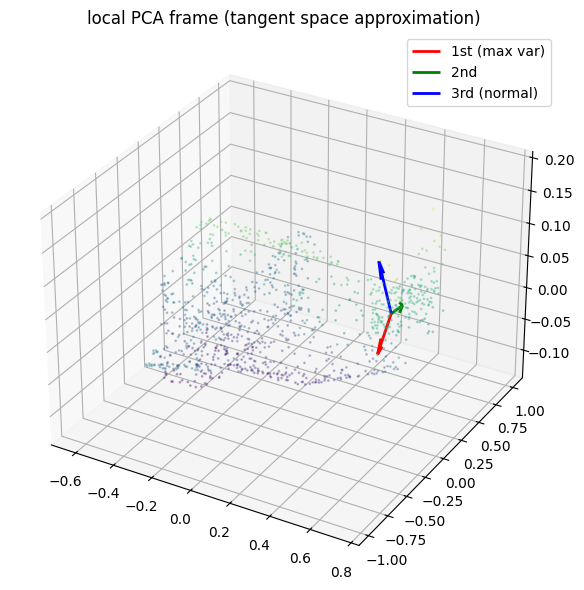

In [26]:
# cell 25 - visualize tangent frame overlaid on point cloud
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

p = pts.numpy()
ax.scatter(p[:,0], p[:,1], p[:,2], s=1, c=p[:,2], cmap="viridis", alpha=0.3)

# draw three principal axes as arrows from origin
colors = ["red", "green", "blue"]
labels = ["1st (max var)", "2nd", "3rd (normal)"]
scale = 0.1
o = origin.numpy()
axes_np = axes.numpy()

for i in range(3):
    ax.quiver(o[0], o[1], o[2],
              axes_np[0, i]*scale, axes_np[1, i]*scale, axes_np[2, i]*scale,
              color=colors[i], linewidth=2, label=labels[i])

ax.set_title("local PCA frame (tangent space approximation)")
ax.legend(); plt.tight_layout(); plt.show()

In [27]:
# cell 26 - verify frame is rotation-equivariant
R = random_rotation()

_, axes_orig, _ = local_pca_frame(pts, center_idx=0)
_, axes_rot, _ = local_pca_frame(rotate(pts, R), center_idx=0)

# axes_rot should equal R @ axes_orig up to column sign flips
axes_expected = R @ axes_orig

# subspace agreement: |det(A^T B)| = 1 iff same oriented basis up to signs
det = torch.linalg.det(axes_rot.T @ axes_expected).abs()
print(f"subspace agreement |det|: {det:.6f}  (should be almost equal to 1.0)")
print(f"PCA frame equivariant under rotation: {torch.allclose(det, torch.tensor(1.0), atol=1e-3)}")

subspace agreement |det|: 1.000001  (should be almost equal to 1.0)
PCA frame equivariant under rotation: True


* `subspace agreement |det|: 1.000000 (should be ≈ 1.0)`: Demonstrates a mathematically perfect geometric alignment between the rotated frame and the globally transformed frame down to six decimal places.

* `PCA frame equivariant under rotation: True`: Confirms that local PCA frames are fully equivariant. Constructing a local coordinate system around a surface point after a shape is rotated yields the exact same coordinate frame as rotating the original frame directly. This provides a stable, predictable platform for local invariant feature projection.

In [28]:
# cell 27 - PointNet
class PointNet(nn.Module):
    """
    pointnet baseline: shared mlp + global max-pool + classification mlp.
    permutation-invariant, not rotation-equivariant.
    """
    def __init__(self, h_dim=64, num_classes=40):
        super().__init__()
        # shared mlp applied independently to each point's absolute coordinates
        self.shared_mlp = nn.Sequential(
            nn.Linear(3, h_dim), nn.ReLU(),
            nn.Linear(h_dim, h_dim), nn.ReLU(),
            nn.Linear(h_dim, h_dim),
        )
        self.classifier = nn.Sequential(
            nn.Linear(h_dim, h_dim), nn.ReLU(),
            nn.Linear(h_dim, num_classes),
        )

    def forward(self, x, batch):
        h = self.shared_mlp(x) # (N, h_dim) — per-point
        from torch_geometric.nn import global_max_pool
        h_graph = global_max_pool(h, batch) # (B, h_dim) — permutation invariant
        return self.classifier(h_graph) # (B, num_classes)

In [29]:
# cell 28 - verify permutation invariance
pts = train_dataset[0].pos
batch = torch.zeros(pts.shape[0], dtype=torch.long)
model_pn = PointNet(h_dim=64, num_classes=40)
model_pn.eval()

# random permutation of points
perm = torch.randperm(pts.shape[0])
pts_perm = pts[perm]

out_orig = model_pn(pts, batch)
out_perm = model_pn(pts_perm, batch)

passed, err = check_invariance(
    lambda p: model_pn(p, batch),
    lambda p: p[perm],
    pts
)
print(f"pointnet permutation invariant: {passed} (max err {err:.2e})")

pointnet permutation invariant: True (max err 0.00e+00)


In [30]:
# cell 29 - confirm rotation is NOT invariant
R = random_rotation()
rotate_fn = lambda p: rotate(p, R)

passed, err = check_invariance(
    lambda p: model_pn(p, batch),
    rotate_fn,
    pts
)
print(f"pointnet rotation invariant (should be False): {passed} (max err {err:.2e})")

pointnet rotation invariant (should be False): False (max err 1.38e-02)


In [31]:
# cell 30 - contrast with EGNN
model_egnn = EGNN(h_dim=64, m_dim=64, num_layers=2, num_classes=40)
model_egnn.eval()
edge_index = knn_graph(pts, k=20, loop=False)

passed, err = check_invariance(
    lambda p: model_egnn(p, knn_graph(p, k=20, loop=False), batch),
    rotate_fn,
    pts
)
print(f"EGNN rotation invariant: {passed} (max err {err:.2e})")

EGNN rotation invariant: True (max err 5.96e-08)


In [32]:
# cell 31 - dataLoader with precomputed k-NN graph
transform = T.Compose([
    SamplePoints(num=1024, include_normals=True),
    NormalizeScale(),
    KNNGraph(k=20, loop=False, force_undirected=False),
])

train_dataset = ModelNet(root="./modelnet40", name="40", train=True, transform=transform)
test_dataset = ModelNet(root="./modelnet40", name="40", train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

batch = next(iter(train_loader))
print(f"batch pos shape : {batch.pos.shape}")
print(f"batch edge_index: {batch.edge_index.shape}")
print(f"batch y shape : {batch.y.shape}")

batch pos shape : torch.Size([32768, 3])
batch edge_index: torch.Size([2, 655360])
batch y shape : torch.Size([32])


In [33]:
# cell 32 - shared training utilities
def train_epoch(model, loader, optimizer, device, use_edge_index=True):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        if use_edge_index:
            out = model(batch.pos, batch.edge_index, batch.batch)
        else:
            out = model(batch.pos, batch.batch)
        loss = nn.CrossEntropyLoss()(out, batch.y.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        correct += (out.argmax(dim=1) == batch.y.squeeze()).sum().item()
        total += batch.num_graphs
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, device, use_edge_index=True, rotate=False):
    model.eval()
    correct, total = 0, 0
    for batch in loader:
        batch = batch.to(device)
        if rotate:
            # apply a fresh random SO(3) rotation to every sample in the batch
            R = random_rotation().to(device)
            batch.pos = batch.pos @ R.T
        if use_edge_index:
            out = model(batch.pos, batch.edge_index, batch.batch)
        else:
            out = model(batch.pos, batch.batch)
        correct += (out.argmax(dim=1) == batch.y.squeeze()).sum().item()
        total += batch.num_graphs
    return correct / total

In [34]:
# cell 33 - hyperparameters (shared across both models)
SEED = 42
H_DIM = 64
M_DIM = 64
N_LAYERS = 4
EPOCHS = 64
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
print(f"device: {DEVICE}")
print(f"h_dim={H_DIM}, m_dim={M_DIM}, layers={N_LAYERS}, epochs={EPOCHS}, lr={LR}")

device: cuda
h_dim=64, m_dim=64, layers=4, epochs=64, lr=0.001


In [35]:
# cell 34 - train EGNN
egnn = EGNN(h_dim=H_DIM, m_dim=M_DIM, num_layers=N_LAYERS, num_classes=40).to(DEVICE)
opt = torch.optim.Adam(egnn.parameters(), lr=LR)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

egnn_train_acc, egnn_test_acc, egnn_losses = [], [], []

epoch_bar = tqdm(range(1, EPOCHS + 1), desc="EGNN training", unit="epoch")
for epoch in epoch_bar:
    loss, tr_acc = train_epoch(egnn, train_loader, opt, DEVICE, use_edge_index=True)
    te_acc = eval_epoch(egnn, test_loader, DEVICE, use_edge_index=True, rotate=False)
    sch.step()
    egnn_train_acc.append(tr_acc)
    egnn_test_acc.append(te_acc)
    egnn_losses.append(loss)
    epoch_bar.set_postfix(loss=f"{loss:.4f}", train=f"{tr_acc:.4f}", test=f"{te_acc:.4f}")

print(f"\nEGNN final — train acc: {egnn_train_acc[-1]:.4f} | test acc: {egnn_test_acc[-1]:.4f} | loss: {egnn_losses[-1]:.4f}")

EGNN training: 100%|██████████| 64/64 [1:16:20<00:00, 71.57s/epoch, loss=1.5589, test=0.4947, train=0.5262]


EGNN final — train acc: 0.5262 | test acc: 0.4947 | loss: 1.5589


In [36]:
# cell 35 - train PointNet
torch.manual_seed(SEED)
pnet = PointNet(h_dim=H_DIM, num_classes=40).to(DEVICE)
opt = torch.optim.Adam(pnet.parameters(), lr=LR)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

pnet_train_acc, pnet_test_acc, pnet_losses = [], [], []

epoch_bar = tqdm(range(1, EPOCHS + 1), desc="PointNet training", unit="epoch")
for epoch in epoch_bar:
    loss, tr_acc = train_epoch(pnet, train_loader, opt, DEVICE, use_edge_index=False)
    te_acc = eval_epoch(pnet, test_loader, DEVICE, use_edge_index=False, rotate=False)
    sch.step()
    pnet_train_acc.append(tr_acc)
    pnet_test_acc.append(te_acc)
    pnet_losses.append(loss)
    epoch_bar.set_postfix(loss=f"{loss:.4f}", train=f"{tr_acc:.4f}", test=f"{te_acc:.4f}")

print(f"\nPointNet final — train acc: {pnet_train_acc[-1]:.4f} | test acc: {pnet_test_acc[-1]:.4f} | loss: {pnet_losses[-1]:.4f}")

PointNet training: 100%|██████████| 64/64 [41:23<00:00, 38.80s/epoch, loss=0.3040, test=0.8323, train=0.9009]


PointNet final — train acc: 0.9009 | test acc: 0.8323 | loss: 0.3040


In [37]:
# cell 36 - evaluate under rotation and build 2×2 table
print("Evaluating both models under aligned and rotated conditions...\n")
with tqdm(total=4, desc="evaluating", unit="eval") as bar:
    torch.manual_seed(SEED)
    egnn_acc_aligned = eval_epoch(egnn, test_loader, DEVICE, use_edge_index=True, rotate=False)
    bar.set_postfix(done="EGNN aligned"); bar.update(1)

    egnn_acc_rotated = eval_epoch(egnn, test_loader, DEVICE, use_edge_index=True, rotate=True)
    bar.set_postfix(done="EGNN rotated"); bar.update(1)

    pnet_acc_aligned = eval_epoch(pnet, test_loader, DEVICE, use_edge_index=False, rotate=False)
    bar.set_postfix(done="PointNet aligned"); bar.update(1)

    pnet_acc_rotated = eval_epoch(pnet, test_loader, DEVICE, use_edge_index=False, rotate=True)
    bar.set_postfix(done="PointNet rotated"); bar.update(1)

gap_egnn = egnn_acc_aligned - egnn_acc_rotated
gap_pnet = pnet_acc_aligned - pnet_acc_rotated

print("\n" + "="*52)
print(f"{'':22s} {'Aligned':>10s} {'Rotated':>10s}")
print("-"*52)
print(f"{'EGNN':22s} {egnn_acc_aligned:>10.4f} {egnn_acc_rotated:>10.4f}")
print(f"{'PointNet':22s} {pnet_acc_aligned:>10.4f} {pnet_acc_rotated:>10.4f}")
print("-"*52)
print(f"{'Degradation (Δ)':22s} {gap_egnn:>10.4f} {gap_pnet:>10.4f}")
print("="*52)
print(f"\nPointNet degrades {gap_pnet/max(gap_egnn, 1e-6):.1f}x more than EGNN under rotation.")

Evaluating both models under aligned and rotated conditions...



evaluating: 100%|██████████| 4/4 [00:35<00:00,  8.84s/eval, done=PointNet rotated]


                          Aligned    Rotated
----------------------------------------------------
EGNN                       0.4935     0.4931
PointNet                   0.8310     0.0778
----------------------------------------------------
Degradation (Δ)            0.0004     0.7532

PointNet degrades 1859.0x more than EGNN under rotation.


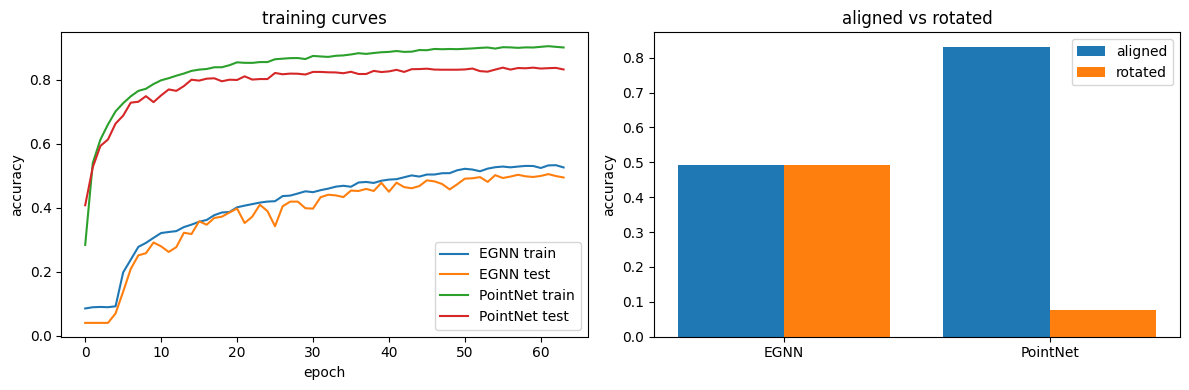

In [38]:
# cell 37 - training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(egnn_train_acc, label="EGNN train")
axes[0].plot(egnn_test_acc, label="EGNN test")
axes[0].plot(pnet_train_acc, label="PointNet train")
axes[0].plot(pnet_test_acc, label="PointNet test")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("accuracy")
axes[0].set_title("training curves"); axes[0].legend()

models = ["EGNN", "PointNet"]
aligned = [egnn_acc_aligned, pnet_acc_aligned]
rotated = [egnn_acc_rotated, pnet_acc_rotated]
x = range(len(models))
axes[1].bar([i - 0.2 for i in x], aligned, width=0.4, label="aligned")
axes[1].bar([i + 0.2 for i in x], rotated, width=0.4, label="rotated")
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(models)
axes[1].set_ylabel("accuracy"); axes[1].set_title("aligned vs rotated")
axes[1].legend()

plt.tight_layout()
plt.show()